In [1]:
pip install numpy nibabel scikit-learn tensorflow matplotlib seaborn reportlab pillow wandb

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import nibabel as nib
 
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, GroupNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model


import matplotlib.pyplot as plt
import gc
import seaborn as sns
import random
from scipy.ndimage import zoom
from skimage.transform import resize

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
from tensorflow.keras import backend as K

#import wandb

2026-09-14 11:08:32.796098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-14 11:08:34.035556: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-14 11:08:34.359243: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-14 11:08:36.643249: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
            print("Memory Growth habilitado para a GPU")
        print("GPU habilitada com sucesso!")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

tf.get_logger().setLevel('ERROR')

Memory Growth habilitado para a GPU
GPU habilitada com sucesso!


I0000 00:00:1789394959.294585    1966 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1789394959.365953    1966 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1789394959.366015    1966 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# FUNÇÕES

# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def load_nifti_paths(base_dir, class_names):
    image_paths = []
    labels = []
    
    # Caminhos das subpastas
    for label in class_names:
        label_dir = os.path.join(base_dir, label)
        for fname in os.listdir(label_dir):
            img_path = os.path.join(label_dir, fname)
            image_paths.append(img_path)
            labels.append(label)

    # Codificando os rótulos
    label_encoder = LabelEncoder()

    # Inverter a ordem das classes explicitamente
    label_encoder.classes_ = np.array(class_names)

    # Convertendo a lista de rótulos para um array NumPy
    labels_array = np.array(labels)

    # Codificando os rótulos (agora 'cn' será 0 e 'ad' será 1)
    labels_encoded = label_encoder.transform(labels_array)

    # Transformando os rótulos para one-hot encoding
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Embaralhar os dados
    image_paths, labels_one_hot = shuffle(image_paths, labels_one_hot, random_state=42)

    return image_paths, labels_one_hot, label_encoder.classes_

def load_nifti_data_balanced(base_dir, class_names, target=1000):
    images = []
    labels = []
    paths = []
    
    # Caminhos das subpastas
    for label in class_names:
        print(f"carregando diretório {label}")
        label_dir = os.path.join(base_dir, label)
        count = 0

        names = os.listdir(label_dir)
        #np.random.shuffle(names)
        for fname in names:
            #if count < target:
            img_path = os.path.join(label_dir, fname)
            img = nib.load(img_path).get_fdata(dtype=np.float16)
            paths.append(img_path)
            images.append(img)
            labels.append(label)
            count += 1

        print(f"diretório carregado {count}")

    # Codificando os rótulos
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Convertendo para arrays NumPy
    images = np.array(images).reshape((-1, *images[0].shape, 1))
    labels_one_hot = np.array(labels_one_hot)
    
    # Embaralhar os dados
    images, labels_one_hot, paths = shuffle(images, labels_one_hot, paths, random_state=42)
    
    return images, labels_one_hot, paths, label_encoder.classes_

def nifti_data_generator_3d(images_array, labels, batch_size):
    total_n = len(images_array)
    
    while True:
        for i in range(0, total_n, batch_size):
            final = min(i + batch_size, total_n)
            batch_images = np.array(images_array[i: final])
            batch_labels = np.array(labels[i:final])

            # Liberar memória
            gc.collect()
            
            yield batch_images, batch_labels


# Função para carregar imagens NIfTI, seus rótulos e cortar as imagens
def nifti_data_generator_3d_path(image_paths, labels, batch_size, size):
    cache_size = batch_size*size
    while True:
        for i in range(0, len(image_paths), cache_size):
            final = min(i + cache_size, len(image_paths))
            batch_paths = image_paths[i:final]
            batch_labels = labels[i:final]
            images = []

            for path in batch_paths:
                # Carregar a imagem NIfTI e garantir o formato correto
                img = nib.load(path).get_fdata(dtype=np.float16)  # Shape original: 
                img = img[..., np.newaxis]       # Adicionar a dimensão do canal: 
                images.append(img)
            
            # Converter lista para array NumPy e garantir o shape correto
            images = np.array(images) 
            batch_labels = np.array(batch_labels)

            # Liberar memória
            gc.collect()
            
            yield images, batch_labels

            import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_probs, output_dir, mode, title):
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:
        y_true = np.argmax(y_true, axis=1)

    if len(y_probs.shape) > 1 and y_probs.shape[1] > 1:
        y_probs = y_probs[:, 1]

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel('False Positive Rate', fontsize=18)
    plt.ylabel('True Positive Rate', fontsize=18)
    plt.title(f'Receiver Operating Characteristic ({title})', fontsize=24)
    plt.legend(loc="lower right", fontsize=15)
    
    plt.savefig(os.path.join(output_dir, f'roc_curve_{mode}.png'))
    plt.show()
    plt.close()
    
    print(f"AUC ({mode}): {roc_auc:.4f}")

# realizar predições e armazenar em um vetor
def get_predictions(images, labels, batch_size, best_model, dir, subset, title):
    pred = []

    for i in range(0, len(images), batch_size):
        final = min(i + batch_size, len(images))
        
        # Fazendo predição para o lote atual
        batch_pred = best_model.predict(images[i:final])
        pred.append(batch_pred)

    # Concatenando as predições e os rótulos verdadeiros
    pred = np.concatenate(pred)

    # Chamar a função
    plot_roc_curve(labels, pred, dir, subset, title)

    # Convertendo as predições para rótulos (a classe com maior probabilidade)
    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(pred, axis=1)
    return pred_labels, true_labels, pred

# gerar curva AUC
def save_auc(test_pred, test_true_labels, results_dir, subset):
    if len(test_pred.shape) > 1 and test_pred.shape[1] > 1:
        y_probs = test_pred[:, 1]
    else:
        y_probs = test_pred

    auc_value = roc_auc_score(test_true_labels, y_probs)

    # Salvar o valor em um arquivo de texto
    with open(os.path.join(results_dir, f"{subset}_auc.txt"), "w") as f:
        f.write(f"AUC Score: {auc_value:.4f}")

    print(f"AUC da Validação: {auc_value:.4f}")

def plot_training_history(history, dir):
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graphic')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.savefig(os.path.join(dir, 'training_history.png'))

    plt.show()

def plot_confusion_matrix(y_true, y_pred, dir, subset, class_names, title):
    # Calcular a matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # Plotando a matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,  annot_kws={"size": 20})
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.xlabel('Predictions', fontsize=24)
    plt.ylabel('Ground Truth', fontsize=24)
    plt.title(f'Confusion Matrix ({title})', fontsize=28)
    plt.savefig(f'{dir}/{subset}_confusion_matrix.png')
    plt.show()

def get_classification_report(y_true, y_pred, dir, subset):
    # Gerar relatório
    report = classification_report(y_true, y_pred)
    print(report)

    # Escrevendo o relatório em um arquivo .txt
    with open(os.path.join(dir, f"{subset}_classification_report.txt"), "w") as file:
        file.write(report)

    # Função para carregar uma imagem NIfTI e extrair uma fatia específica do eixo Z
def load_nifti_image_pdf(file_path):
    img = nib.load(file_path) 
    data = img.get_fdata(dtype=np.float16)  
    slice_2d = data[2, :, :]

    # implementar lógica de retornar vetor com cada fatia como imagem única

    return slice_2d

# Função para criar o PDF
def create_pdf(y_paths, y_images, y_true_labels, y_pred_labels, y_pred, output_pdf_path, class_names):
    c = canvas.Canvas(output_pdf_path, pagesize=letter)
    width, height = letter  # Dimensões da página no PDF

    #for image, name in zip(y_images, y_paths):
    for i in range(0, len(y_images)):
        true = ''
        pred = ''
        # Carregar a imagem NIfTI e obter a fatia 2D no eixo Z
        # nifti_image = load_nifti_image_pdf(item)
        nifti_image = y_images[i][:, :, 88, 0]

        # Converter a fatia 2D para uma imagem 8-bit (grayscale) para visualização
        img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
        img = img.convert("RGB")  # Garantir que a imagem tenha 3 canais (RGB)

        # Redimensionar a imagem para se ajustar ao tamanho da página
        img_width, img_height = img.size
        aspect_ratio = img_height / float(img_width)
        new_width = width * 0.2  # Definir largura como 80% da largura da página
        new_height = new_width * aspect_ratio
        img = img.resize((int(new_width), int(new_height)))

        # Criar um arquivo temporário para salvar a imagem
        with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as temp_file:
            temp_file_path = temp_file.name
            img.save(temp_file_path)

        # configurar para printar as 7 fatias em uma página inteira, com as informações de label predito e esperado

        # Colocar a imagem no PDF usando o caminho temporário
        if i % 12 < 4:
            x = 80
        elif i % 12 < 8:
            x = width - 2.35*new_width - 80
        else:
            x = width - new_width - 80

        y = height - (new_height + 80)*((i%4)+1)

        c.drawImage(temp_file_path, x, y, width=new_width, height=new_height)

        # Escrever os rótulos
        true_label = y_true_labels[i]
        pred_label = y_pred_labels[i]

        #ver como transformar os labels de maneira inteligente
        true = class_names[true_label]
        pred = class_names[pred_label]

        # Definir a cor para os rótulos
        if true_label == pred_label:
            pred_color = (0, 1, 0)  # Verde
        else:
            pred_color = (1, 0, 0)  # Vermelho
        
        #Nome paciente (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+24, y+new_height+50, f"{os.path.basename(y_paths[i])}")

        # Rótulo esperado (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+26, y+new_height+35, f"Expected: {true}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+20, f"Predicted: {pred}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+5, f"Prob: {max(y_pred[i])*100:.2f}%")

        # Avançar para a próxima imagem
        i += 1
        
        # Adicionar uma nova página no PDF a cada 2 imagens (se necessário)
        if i % 12 == 0:  # Por exemplo, a cada 2 imagens, adicionamos uma nova página
            c.showPage()

    # Salvar o PDF
    c.save()

def create_model_3d_best(input_shape, n_classes):
    model = Sequential([        
        Input(shape=input_shape),  # Formato de entrada: (1, 145, 182, 155)

        # Camada 1 - Filtro 3x3
        Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        LeakyReLU(negative_slope=0.3),  
        MaxPooling3D(pool_size=(2, 2, 2), padding='same'),
        Dropout(0.4),

        # Camada 2 - Filtro 5x5
        Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        LeakyReLU(negative_slope=0.3),  
        MaxPooling3D(pool_size=(2, 2, 2), padding='same'),
        Dropout(0.4),

        # Camada 3 - Filtro 5x5
        Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        LeakyReLU(negative_slope=0.3),  
        MaxPooling3D(pool_size=(2, 2, 2), padding='same'),
        Dropout(0.4),

        # Camada de saída convolucional
        Flatten(),

        # Camadas densas
        Dense(16, kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        Dropout(0.4),
        LeakyReLU(negative_slope=0.3),  

        # Camadas densas
        Dense(8, kernel_regularizer=l2(0.01)),
        BatchNormalization()(),
        Dropout(0.4),
        LeakyReLU(negative_slope=0.3),  

        # Camada de saída
        Dense(n_classes, activation='softmax')
    ])
    
    return model

def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(32, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)
    
    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(32, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

def plot_training_history_gradcam(history, dir):
    # Criamos 3 subplots agora
    plt.figure(figsize=(18, 5))

    # 1. Plot Loss Total e de Classificação
    plt.subplot(1, 3, 1)
    plt.plot(history.history['total_loss'], label='Total Loss (BCE + SFR)')
    if 'classification_loss' in history.history:
        plt.plot(history.history['classification_loss'], label='Classification Loss (BCE)')
    plt.title('Loss Analysis')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # 2. Plot Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(history.history['categorical_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # 3. Plot Saliency Loss (A "punição" do Grad-CAM)
    plt.subplot(1, 3, 3)
    if 'saliency_loss' in history.history:
        plt.plot(history.history['saliency_loss'], label='Saliency Loss (SFR)', color='red')
        plt.title('Saliency Regularization Term')
        plt.xlabel('Epochs')
        plt.ylabel('Penalty Intensity')
        plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(dir, 'training_history_gradcam.png'))
    plt.show()

In [5]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED"

train_dir = f'{dir_base}/train'
val_dir = f'{dir_base}/validation'
test_dir = f'{dir_base}/test'
results_dir = f'{dir_base}/results/ieee_sfr'
os.makedirs(results_dir, exist_ok=True)

# class_names = ['cn', 'emci', 'mci', 'lmci', 'ad']
class_names = ['cn', 'ad']

n_classes = len(class_names)

In [6]:
n = len(os.listdir(results_dir))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir, f'test_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir, f"test_{n}")):
            os.remove(os.path.join(results_dir,  f"test_{n}", item))
        os.removedirs(os.path.join(results_dir, f'test_{n}'))
        n -= 1

folder_name = f"test_{str(n+1)}"
results_dir = os.path.join(results_dir, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_1 criada


In [7]:
train_images, train_labels, train_paths, class_labels = load_nifti_data_balanced(train_dir, class_names)
input_shape = train_images[0].shape
print(f"N treino: {len(train_paths)}")

carregando diretório cn
diretório carregado 530
carregando diretório ad
diretório carregado 534
N treino: 1064


In [8]:
val_images, val_labels, val_paths, _ = load_nifti_data_balanced(val_dir, class_names)
input_shape = val_images[0].shape
print(f"N validation: {len(val_paths)}")
# input shape 156, 195, 160
val_images[0].shape

carregando diretório cn
diretório carregado 137
carregando diretório ad
diretório carregado 152
N validation: 289


(156, 195, 160, 1)

## Treino com Grad-CAM

In [9]:
print(os.listdir('../pre_processing/mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/'))

# Carregar máscara
mask = nib.load('../pre_processing/mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/mni_icbm152_t1_tal_nlin_asym_09c_mask.nii').get_fdata()
mask_crop = mask[18:174, 17:212, 15:175]

mask_crop = resize(mask_crop, (18, 22, 18), order=0, preserve_range=True, anti_aliasing=False)
mask_crop = (mask_crop > 0.5).astype(float)
mask_crop = 1.0 - mask_crop
mask_crop = tf.cast(mask_crop, tf.float16)

['mni_icbm152_csf_tal_nlin_asym_09c.nii', 'mni_icbm152_gm_tal_nlin_asym_09c.nii', 'mni_icbm152_pd_tal_nlin_asym_09c.nii', 'mni_icbm152_t1_tal_nlin_asym_09c.nii', 'mni_icbm152_t1_tal_nlin_asym_09c_eye_mask.nii', 'mni_icbm152_t1_tal_nlin_asym_09c_face_mask.nii', 'mni_icbm152_t1_tal_nlin_asym_09c_mask.nii', 'mni_icbm152_t2_tal_nlin_asym_09c.nii', 'mni_icbm152_wm_tal_nlin_asym_09c.nii']


I0000 00:00:1789395194.711135    1966 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1789395194.711225    1966 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1789395194.711264    1966 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1789395194.942899    1966 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1789395194.942973    1966 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-14

(18, 22, 18)


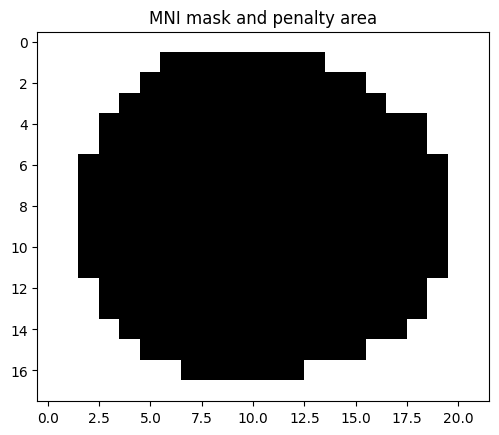

In [10]:
# print(train_images[0].shape)
print(mask_crop.shape)
plt.imshow(mask_crop[:, :, 10], cmap='grey', alpha=1)
# plt.imshow(train_images[0][:, :, 90], cmap='grey', alpha=1)
plt.title("MNI mask and penalty area")
plt.show()

In [11]:
def custom_binary_crossentropy(y_true, y_pred, alpha, mean_grad):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

    term1 = y_true * tf.math.log(y_pred)
    term2 = (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    term3 = alpha * tf.sum(tf.multiply(mask_crop, mean_grad))

    loss_individual = -(term1 + term2 + term3)

    return tf.reduce_mean(loss_individual, axis=-1) # Retorna a média da perda para o batch inteiro (se quiser mudar, fica a seu critério)

In [12]:
import tensorflow as tf

class SFRModel(tf.keras.Model):
    def __init__(self, model, alpha, mask_crop, last_conv_layer_name, **kwargs):
        super(SFRModel, self).__init__(**kwargs)
        
        self.model = model
        self.alpha = alpha
        self.mask_crop = tf.cast(mask_crop, tf.float32)
        self.last_conv_layer_name = last_conv_layer_name
        
        # O Keras rastreia esses atributos automaticamente!
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.saliency_tracker = tf.keras.metrics.Mean(name="saliency_loss")
        self.classification_tracker = tf.keras.metrics.Mean(name="classification_loss")
        
        # Inicialização do modelo de gradiente
        try:
            conv_layer = self.model.get_layer(self.last_conv_layer_name)
            self.grad_model = tf.keras.models.Model(
                [self.model.inputs], [conv_layer.output, self.model.output]
            )
        except Exception as e:
            print(f"Aviso: Não foi possível criar o grad_model na inicialização: {e}")

    def get_config(self):
        base_config = super(SFRModel, self).get_config()
        config = {
            "model": self.model, 
            "alpha": self.alpha,
            "mask_crop": self.mask_crop.numpy() if hasattr(self.mask_crop, "numpy") else self.mask_crop,
            "last_conv_layer_name": self.last_conv_layer_name,
        }
        return {**base_config, **config}

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    def train_step(self, data):
        x, y = data
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.float32)

        with tf.GradientTape() as total_tape:
            with tf.GradientTape() as gradcam_tape:
                conv_outputs, predictions = self.grad_model(x, training=True)
                class_loss = predictions[:, 1]

            grads = gradcam_tape.gradient(class_loss, conv_outputs)
            pooled_grads = tf.reduce_mean(grads, axis=(1, 2, 3))
            heatmap = tf.reduce_sum(tf.multiply(pooled_grads[:, tf.newaxis, tf.newaxis, tf.newaxis, :], conv_outputs), axis=-1)
            heatmap = tf.nn.relu(heatmap)

            heatmap_norm = heatmap / (tf.reduce_sum(heatmap, axis=(1, 2, 3), keepdims=True) + 1e-6)
            saliency_penalty_batch = tf.reduce_sum(heatmap_norm * self.mask_crop, axis=(1, 2, 3))
            mean_saliency_penalty = tf.reduce_mean(saliency_penalty_batch)

            # compute_loss atualiza o tracker interno "loss" automaticamente (com o main_loss)
            main_loss = self.compute_loss(x=x, y=y, y_pred=predictions)
            total_loss = main_loss + (self.alpha * mean_saliency_penalty)

        gradients = total_tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.saliency_tracker.update_state(mean_saliency_penalty)
        self.classification_tracker.update_state(main_loss)

        logs = {
            "total_loss": self.total_loss_tracker.result(),
            "saliency_loss": self.saliency_tracker.result(),
            "classification_loss": self.classification_tracker.result(),
        }
        for metric in self.metrics:
            if metric.name in ("total_loss", "saliency_loss", "classification_loss", "loss"):
                continue
            metric.update_state(y, predictions)
            result = metric.result()
            if isinstance(result, dict):
                logs.update(result)
            else:
                logs[metric.name] = result

        return logs
    
    def test_step(self, data):
        x, y = data
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.float32)

        with tf.GradientTape() as gradcam_tape:
            conv_outputs, predictions = self.grad_model(x, training=False)
            class_loss = predictions[:, 1]

        grads = gradcam_tape.gradient(class_loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(1, 2, 3))
        heatmap = tf.reduce_sum(
            tf.multiply(pooled_grads[:, tf.newaxis, tf.newaxis, tf.newaxis, :], conv_outputs),
            axis=-1
        )
        heatmap = tf.nn.relu(heatmap)

        heatmap_norm = heatmap / (tf.reduce_sum(heatmap, axis=(1, 2, 3), keepdims=True) + 1e-6)
        saliency_penalty_batch = tf.reduce_sum(heatmap_norm * self.mask_crop, axis=(1, 2, 3))
        mean_saliency_penalty = tf.reduce_mean(saliency_penalty_batch)

        main_loss = self.compute_loss(x=x, y=y, y_pred=predictions)
        total_loss = main_loss + (self.alpha * mean_saliency_penalty)

        self.total_loss_tracker.update_state(total_loss)
        self.saliency_tracker.update_state(mean_saliency_penalty)
        self.classification_tracker.update_state(main_loss)

        logs = {
            "total_loss": self.total_loss_tracker.result(),
            "saliency_loss": self.saliency_tracker.result(),
            "classification_loss": self.classification_tracker.result(),
        }
        for metric in self.metrics:
            if metric.name in ("total_loss", "saliency_loss", "classification_loss", "loss"):
                continue
            metric.update_state(y, predictions)
            result = metric.result()
            if isinstance(result, dict):
                logs.update(result)
            else:
                logs[metric.name] = result

        return logs
    
    @property
    def metrics(self):
        return super().metrics

    def call(self, x):
        return self.model(x)

In [13]:
K.clear_session()

loading_model = create_model_3d(train_images[0].shape, n_classes)
loading_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 156, 195, 160,  │           224 │
│                                 │ 8)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            32 │
│ (BatchNormalization)            │ 8)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 8)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 52, 65, 54, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 52, 65, 54, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 65, 54, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 52, 65, 54, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 22, 18, 16) │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 22, 18, 32) │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 22, 18, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 22, 18, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 8, 6, 32)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 8, 6, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       294,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             

 Total params: 313,474 (1.20 MB)

 Trainable params: 313,266 (1.20 MB)

 Non-trainable params: 208 (832.00 B)

In [14]:
SFR_model = SFRModel(
    model=loading_model, 
    alpha=0.00, 
    mask_crop=mask_crop, 
    last_conv_layer_name='conv3d_2'
)

SFR_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy")]
)

SFR_model.build(input_shape)

SFR_model.summary()

Model: "sfr_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 2)              │       313,474 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ ((None, 18, 22, 18,    │       313,474 │
│                                 │ 32), (None, 2))        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,474 (1.20 MB)

 Trainable params: 313,266 (1.20 MB)

 Non-trainable params: 208 (832.00 B)

In [15]:
batch_size = 16

steps_per_epoch = len(train_paths) // batch_size
validation_steps = len(val_paths) // batch_size

train_generator = nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = nifti_data_generator_3d(val_images, val_labels, batch_size)

epochs = 100

new_model_name_ker = (f"gradcam_binary_classifier_{epochs}_epochs_batch_{batch_size}_{n_classes}_classes.keras")

# Parar caso fique {patience} épocas sem melhora
early_stopping = EarlyStopping(
    monitor='val_loss',     
    patience=30,                 
    verbose=1
)

# Defina o nome do arquivo para salvar o melhor modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(results_dir, new_model_name_ker),    
    monitor='val_categorical_accuracy',
    save_best_only=True, 
    mode='max', 
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)

log_path = os.path.join(results_dir, 'log_treino.csv')

csv_log = CSVLogger(log_path, append=False)

In [16]:
print(f"Iniciando treinamento SFR (Saliency Feedback Regularization)")

# Treinamento usando o SFR_model
history = SFR_model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[model_checkpoint_callback, reduce_lr, csv_log]
)

Iniciando treinamento SFR (Saliency Feedback Regularization)
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(None, 156, 195, 160, 1))']
  warnings.warn(msg)
I0000 00:00:1789395202.518568    3776 service.cc:146] XLA service 0x7f35a40074f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789395202.518646    3776 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-09-14 11:13:22.864334: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-14 11:13:23.560243: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-09-14 11:13:27.027581: W external/local_tsl/tsl/framework/bfc_al

66/66 ━━━━━━━━━━━━━━━━━━━━ 70s 440ms/step - categorical_accuracy: 0.5701 - classification_loss: 2.0759 - saliency_loss: 0.4283 - total_loss: 2.0759 - val_categorical_accuracy: 0.5278 - val_classification_loss: 1.9500 - val_saliency_loss: 0.8684 - val_total_loss: 1.9500 - learning_rate: 5.0000e-04
Epoch 2/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: categorical_accuracy,classification_loss,saliency_loss,total_loss,val_categorical_accuracy,val_classification_loss,val_saliency_loss,val_total_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
2026-09-14 11:14:30.643890: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.1594 = f32[8,18,22,18,16]{4,3,2,1,0} reduce-window(f32[8,52,65,54,16]{4,3,2,1,0} %broadcast.1583, f32[] %constant.1584), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x1_1x0_1x0_0x0_0}, to_apply=%region_1.1590, metadata={op_type="AvgPool3D" op_name="functional_1_1/average_pooling3d_1_2/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off bet

66/66 ━━━━━━━━━━━━━━━━━━━━ 52s 395ms/step - categorical_accuracy: 0.6355 - classification_loss: 1.9001 - saliency_loss: 0.4256 - total_loss: 1.9001 - val_categorical_accuracy: 0.5174 - val_classification_loss: 2.7969 - val_saliency_loss: 0.6041 - val_total_loss: 2.7969 - learning_rate: 5.0000e-04
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - categorical_accuracy: 0.6796 - classification_loss: 1.7625 - saliency_loss: 0.4206 - total_loss: 1.7625

2026-09-14 11:15:45.625665: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce-window.209 = f32[1,52,65,54,8]{4,3,2,1,0} reduce-window(f32[1,156,195,160,8]{4,3,2,1,0} %broadcast.198, f32[] %constant.199), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x0_0x0_0x1_1x0_0}, to_apply=%region_1.205, metadata={op_type="AvgPool3D" op_name="functional_1_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-09-14 11:15:47.573822: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.948281621s
Constant folding an instruc

66/66 ━━━━━━━━━━━━━━━━━━━━ 32s 490ms/step - categorical_accuracy: 0.6784 - classification_loss: 1.7478 - saliency_loss: 0.4069 - total_loss: 1.7478 - val_categorical_accuracy: 0.5421 - val_classification_loss: 4.2771 - val_saliency_loss: 0.4754 - val_total_loss: 4.2771 - learning_rate: 5.0000e-04
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 390ms/step - categorical_accuracy: 0.7013 - classification_loss: 1.6605 - saliency_loss: 0.3926 - total_loss: 1.6605 - val_categorical_accuracy: 0.5201 - val_classification_loss: 2.6148 - val_saliency_loss: 0.6221 - val_total_loss: 2.6148 - learning_rate: 5.0000e-04
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 393ms/step - categorical_accuracy: 0.7347 - classification_loss: 1.5595 - saliency_loss: 0.3584 - total_loss: 1.5595 - val_categorical_accuracy: 0.5092 - val_classification_loss: 2.4966 - val_saliency_loss: 0.5284 - val_total_loss: 2.4966 - learning_rate: 5.0000e-04
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 396ms/step - categorical_accuracy: 0.74

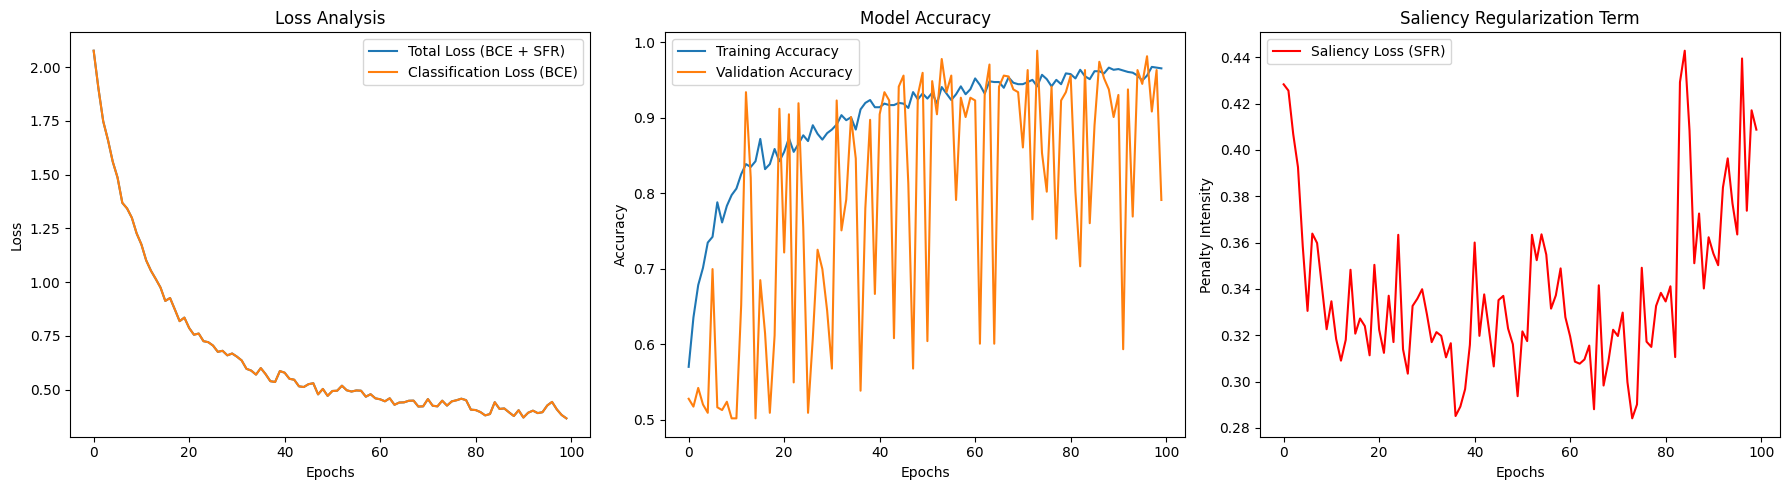

In [17]:
# Plotando o histórico de treinamento após o treinamento
plot_training_history_gradcam(history, results_dir)

### PREDIÇÃO VALIDAÇÃO

In [18]:
# results_dir = os.path.join('/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/neurips_results/grad_loss_mask_pre/test_4')
model_path = os.path.join(results_dir, os.listdir(results_dir)[0])
model_title = r"$\beta=0.1$"

print(f"modelo {model_title}: {model_path}")
print("resultados: " + results_dir)
print(f"\n\n\n")

SFR_model.load_weights(model_path)

modelo $\beta=0.1$: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/ieee_sfr/test_1/gradcam_binary_classifier_100_epochs_batch_16_2_classes.keras
resultados: /mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/ieee_sfr/test_1






In [19]:
# Baseline model
results_dir = os.path.join('/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/neurips_results/baseline_model/test_1')
modelito_path = os.path.join(results_dir, os.listdir(results_dir)[0])
model_title = r"Baseline"
modelito = load_model(modelito_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


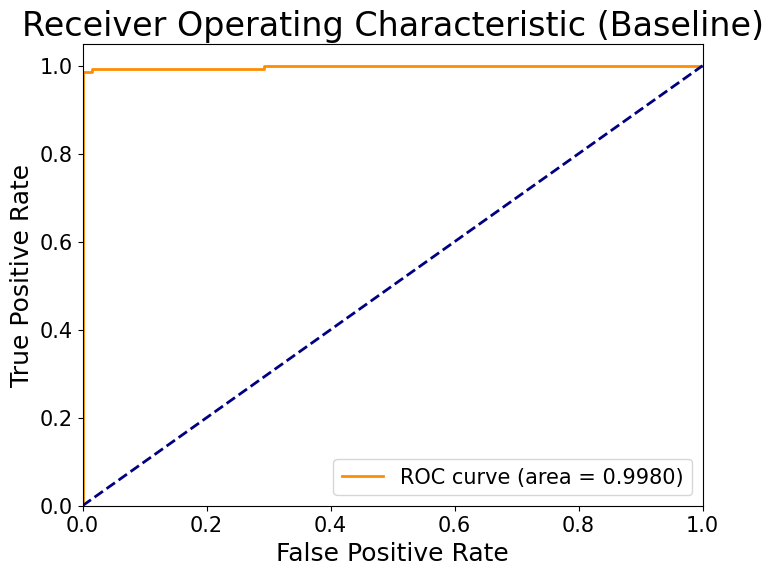

AUC (validation): 0.9980
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       137
           1       1.00      0.99      0.99       152

    accuracy                           0.99       289
   macro avg       0.99      0.99      0.99       289
weighted avg       0.99      0.99      0.99       289



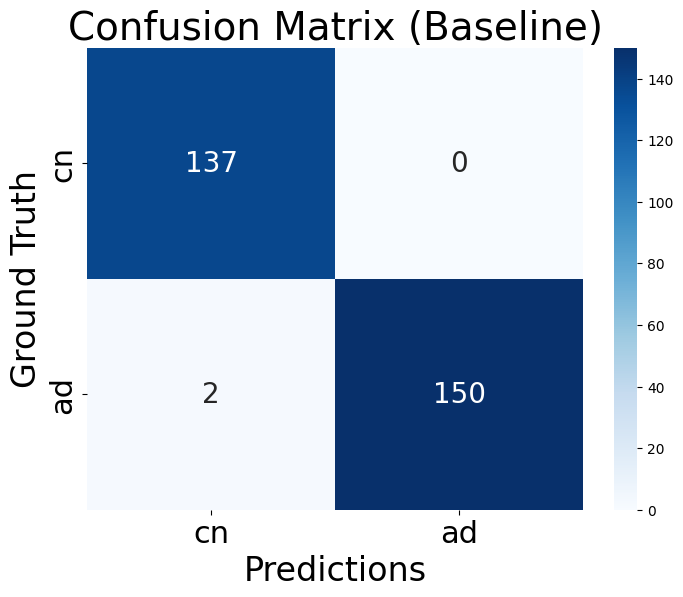

AUC da Validação: 0.9980


In [20]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = get_predictions(val_images, val_labels, batch_size, SFR_model, results_dir, 'validation', model_title)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(val_true_labels, val_pred_labels, results_dir, 'val')

# Obter matriz de confusão
plot_confusion_matrix(val_true_labels, val_pred_labels, results_dir, 'val', class_names, model_title)

# Criar pdf com predições
val_pdf_path = os.path.join(results_dir, "validation_predictions.pdf")
create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, class_names)

save_auc(val_pred, val_true_labels, results_dir, 'validation')

### PREDIÇÃO TESTE

In [21]:
test_images, test_labels, test_paths, _ = load_nifti_data_balanced(test_dir, class_names)

carregando diretório cn
diretório carregado 73
carregando diretório ad
diretório carregado 76


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


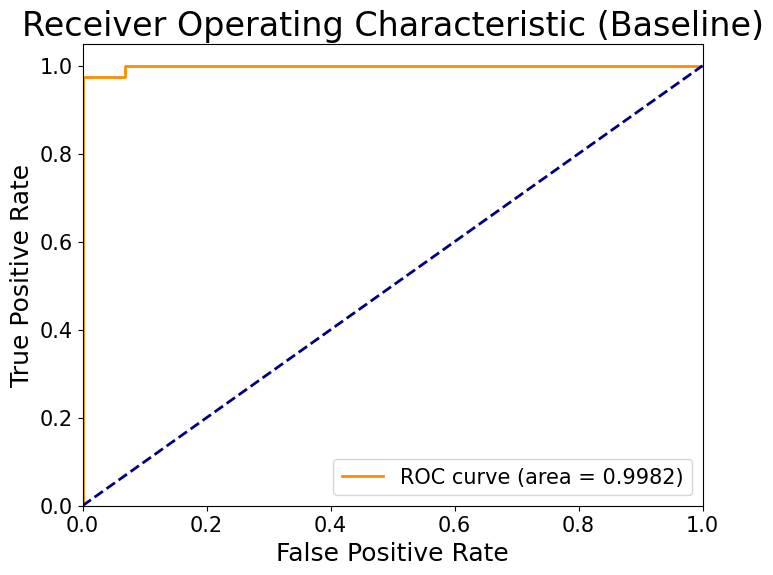

AUC (test): 0.9982
              precision    recall  f1-score   support

           0       0.97      0.96      0.97        73
           1       0.96      0.97      0.97        76

    accuracy                           0.97       149
   macro avg       0.97      0.97      0.97       149
weighted avg       0.97      0.97      0.97       149



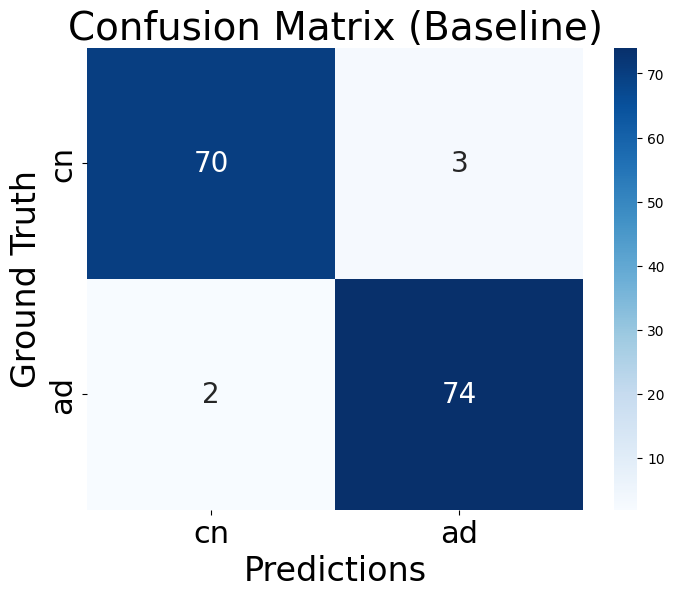

AUC da Validação: 0.9982


In [22]:
# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = get_predictions(test_images, test_labels, batch_size, SFR_model, results_dir, 'test', model_title)

# Obter métricas da valiadação e salvá-las em um arquivo
get_classification_report(test_true_labels, test_pred_labels, results_dir, 'test')

# Obter matriz de confusão
plot_confusion_matrix(test_true_labels, test_pred_labels, results_dir, 'test', class_names, model_title)

# Criar pdf com predições
test_pdf_path = os.path.join(results_dir, "test_predictions.pdf")
create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, class_names)

save_auc(test_pred, test_true_labels, results_dir, 'test')

In [23]:
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm

def get_gradcam_3d(model, volume, class_index, last_conv_layer_name):

    base_model = model.model if hasattr(model, 'model') else model

    grad_model = tf.keras.models.Model(
        [base_model.inputs], 
        [base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        volume_float32 = tf.cast(volume, tf.float32)
        # O modelo espera um batch, então expandimos a dimensão
        conv_outputs, predictions = grad_model(tf.expand_dims(volume_float32, axis=0))
        loss = predictions[:, class_index]
    
    grads = tape.gradient(loss, conv_outputs)
    
    # Faz o cast explícito para float32 para evitar erros de tipo
    conv_outputs = tf.cast(conv_outputs, tf.float32)
    grads = tf.cast(grads, tf.float32)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))  # média global

    # Pondera os mapas de ativação
    conv_outputs = conv_outputs[0]
    heatmap = tf.zeros(conv_outputs.shape[:-1], dtype=tf.float32)

    for i in range(pooled_grads.shape[0]):
        heatmap += pooled_grads[i] * conv_outputs[..., i]

    heatmap = tf.nn.relu(heatmap)
    # heatmap = tf.abs(heatmap)
    heatmap = heatmap / tf.reduce_max(heatmap + 1e-6)
    
    return heatmap.numpy()

def resize_heatmap_to_volume(heatmap, target_shape):
    zoom_factors = (
        target_shape[0] / heatmap.shape[0],
        target_shape[1] / heatmap.shape[1],
        target_shape[2] / heatmap.shape[2]
    )
    heatmap_upscaled = zoom(heatmap, zoom_factors, order=1)  # order=1: interpolação linear
    return heatmap_upscaled

def show_gradcam_slice(volume, heatmap, slice_idx=None, axis=0, alpha=0.5, cmap='jet'):
    if slice_idx is None:
        slice_idx = volume.shape[axis] // 2

    if axis == 0:
        img_slice = volume[slice_idx, :, :, 0]
        heatmap_slice = heatmap[slice_idx, :, :]
    elif axis == 1:
        img_slice = volume[:, slice_idx, :, 0]
        heatmap_slice = heatmap[:, slice_idx, :]
    else:
        img_slice = volume[:, :, slice_idx, 0]
        heatmap_slice = heatmap[:, :, slice_idx]

    plt.imshow(img_slice, cmap='gray')
    plt.imshow(heatmap_slice, cmap=cmap, alpha=alpha)
    plt.axis('off')
    plt.title(f'Slice {slice_idx} (Axis {axis})')
    plt.show()

In [24]:
def show_gradcam_all_slices(model, volume, class_idx, axis=2, name='mri', pdf=None, overlay=0.6):
    fig, axes = plt.subplots(1, 7, figsize=(20,5))

    # 1. Predição e Heatmap gerados APENAS UMA VEZ por volume
    prediction = model.predict(volume[np.newaxis, ...], verbose=0)
    prediction = np.argmax(prediction)

    # Gera o volume de saliência completo
    # heatmap_vol = get_gradcam_3d(model, volume, prediction, 'conv3d_2')
    heatmap_vol = get_gradcam_3d(model, volume, 1, 'conv3d_2')
    heatmap_vol = resize_heatmap_to_volume(heatmap_vol, volume.shape)

    i = 0
    for slice_idx in range(80, 115, 5):

        # 2. Apenas extraímos a fatia do volume já calculado
        if axis == 0:
            vol_img = volume[slice_idx, :, :, 0]
            heatmap_slice = heatmap_vol[slice_idx, :, :]

        elif axis == 1:
            vol_img = volume[:, slice_idx, :, 0]
            heatmap_slice = heatmap_vol[:, slice_idx, :]

        else:
            vol_img = volume[:, :, slice_idx, 0]
            heatmap_slice = heatmap_vol[:, :, slice_idx]

        axes[i].imshow(vol_img, cmap='gray')
        axes[i].imshow(heatmap_slice, cmap='jet', alpha=overlay)
        axes[i].axis('off')
        axes[i].set_title(f'Slice {slice_idx}', fontsize=12)
        i += 1

    # Ajuste no título e layout

    real_class = np.argmax(class_idx) if hasattr(class_idx, "__len__") else class_idx
    fig.suptitle(f"Patient: {name} | Real: {real_class} | Pred: {prediction}", fontsize=16)
    plt.tight_layout()

    if pdf:
        pdf.savefig(fig) 
        plt.close(fig)    

    else:
        plt.show()


def multi_slices_data_gradcam(model, images, labels, paths, pdf_path='gradcams.pdf', overlay=0.6):
    with PdfPages(pdf_path) as pdf:
        for volume, index, name in tqdm(zip(images, labels, paths), total=len(images), desc="Gerando Grad-CAMs"):
            show_gradcam_all_slices(model, volume, index, 2, name=os.path.basename(name), pdf=pdf, overlay=overlay)


# show_gradcam_all_slices(SFR_model, test_images[2], test_labels[2], 2, test_paths[2], pdf=None, overlay=0.5) 

# show_gradcam_all_slices(SFR_model, test_images[1], test_labels[1], 2, test_paths[1], pdf=None, overlay=0.5)

multi_slices_data_gradcam(SFR_model, test_images, test_labels, test_paths, f'{results_dir}/gradcams_slices.pdf', overlay=0.6) 
print(results_dir)

Gerando Grad-CAMs:   0%|          | 0/149 [00:00<?, ?it/s]/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 156, 195, 160, 1))']
  warnings.warn(msg)
W0000 00:00:1789397856.442183    1966 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1789397856.502179    1966 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1789397856.525280    1966 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1789397856.546828    1966 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1789397856.575340    1966 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1789

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/neurips_results/baseline_model/test_1


In [25]:
def show_gradcam_all_layers(model, volume, class_idx, slice_idx=None, axis=0, name='mri', pdf=None, overlay=0.6):
    # 1. Definir o slice_idx logo no início
    if slice_idx is None:
        slice_idx = volume.shape[axis] // 2

    # 2. Extrair o vol_img da MRI original ANTES do loop
    if axis == 0:
        vol_img = volume[slice_idx, :, :, 0]
    elif axis == 1:
        vol_img = volume[:, slice_idx, :, 0]
    else:
        vol_img = volume[:, :, slice_idx, 0]

    fig, axes = plt.subplots(1, 4, figsize=(20,4))
    
    # Plotar a MRI original no primeiro eixo imediatamente
    axes[0].imshow(vol_img, cmap='gray')
    axes[0].axis('off')
    axes[0].set_title('MRI', fontsize=18)

    prediction = model.predict(volume[np.newaxis, ...], verbose=0)
    prediction = np.argmax(prediction)

    i = 1

    layers_to_iterate = model.model.layers if hasattr(model, 'model') else model.layers

    for layer in layers_to_iterate:
        # Verifica se é uma camada de convolução e se ainda temos espaço nos 4 subplots
        if layer.name.startswith('conv') and i < 4:
            # heatmap = get_gradcam_3d(model, volume, prediction, layer.name)
            heatmap = get_gradcam_3d(model, volume, 1, layer.name)
            heatmap = resize_heatmap_to_volume(heatmap, volume.shape)

            # Extrair o slice do heatmap baseado no eixo
            if axis == 0:
                heatmap_slice = heatmap[slice_idx, :, :]
            elif axis == 1:
                heatmap_slice = heatmap[:, slice_idx, :]
            else:
                heatmap_slice = heatmap[:, :, slice_idx]

            axes[i].imshow(vol_img, cmap='gray') # Usando vol_img já definido
            axes[i].imshow(heatmap_slice, cmap='jet', alpha=overlay)
            axes[i].axis('off')
            axes[i].set_title(f'Layer: {layer.name}', fontsize=18)
            i += 1

    fig.suptitle(f"Slice {slice_idx} | Patient {name} | True Class {class_idx} | Pred {prediction}", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if pdf:
        pdf.savefig(fig) 
        plt.close(fig)    
    else:
        plt.show()

def multi_layers_data_gradcam(model, images, labels, paths, overlay=0.6, pdf_path='gradcams.pdf'):
    with PdfPages(pdf_path) as pdf:
        for volume, index, name in tqdm(zip(images, labels, paths), total=len(images), desc="Gerando Grad-CAMs"):
            show_gradcam_all_layers(
                model,
                volume,
                np.argmax(index),
                slice_idx=80,
                axis=2,
                name=os.path.basename(name),
                pdf=pdf,
                overlay=overlay
            )

# show_gradcam_all_layers(SFR_model, test_images[2], test_labels[2], 80, 2, test_paths[2], pdf=None, overlay=0.5) 

# show_gradcam_all_layers(SFR_model, test_images[1], test_labels[1], 80, 2, test_paths[1], pdf=None, overlay=0.5) 

multi_layers_data_gradcam(SFR_model, test_images, test_labels, test_paths, 0.6, f'{results_dir}/gradcams_layers_with_overlay.pdf')
print(results_dir)

Gerando Grad-CAMs:   0%|          | 0/149 [00:00<?, ?it/s]/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 156, 195, 160, 1))']
  warnings.warn(msg)
Gerando Grad-CAMs: 100%|██████████| 149/149 [03:30<00:00,  1.41s/it]


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/ADNI/ADNI_NORMALIZED/results/neurips_results/baseline_model/test_1
